#  Trabajo 4: Visualización de datos con Matplotlib y Seaborn

Creación de visualizaciones con Matplotlib y Seaborn para analizar un conjunto de datos de ventas minoristas.

## Requisitos

* Crear al menos un gráfico univariante (histograma, diagrama de barras o diagrama de caja) utilizando Matplotlib
* Crear al menos un gráfico univariante utilizando Seaborn
* Implementar al menos un gráfico bivariante (dispersión, líneas o barras agrupadas) con Matplotlib
* Implementar al menos un gráfico bivariante con Seaborn
* Crear una visualización multivariante (como un gráfico de pares o un heatmap de correlación) con Seaborn
* Personalizar los gráficos (títulos, etiquetas de ejes, paletas de colores)
* Organizar múltiples visualizaciones en una figura usando subplots
* Guardar al menos una figura generada como archivo de imagen
* Incluir comentarios explicativos sobre las conclusiones obtenidas de cada visualización
* Utilizar el dataset superstore_dataset2012.csv proporcionado

## Instrucciones

Configura tu entorno de trabajo
Crea un nuevo archivo Python (.py) o un notebook Jupyter (.ipynb). Importa las bibliotecas necesarias (pandas, matplotlib, seaborn) y carga el dataset superstore_dataset2012.csv que ya está disponible en tu entorno.

Explora y prepara los datos
Realiza una exploración inicial del dataset para entender su estructura. Verifica los tipos de datos, valores nulos y realiza las transformaciones necesarias (como convertir fechas al formato adecuado).

Crea visualizaciones univariantes con Matplotlib
Implementa al menos un histograma o diagrama de barras utilizando Matplotlib para visualizar la distribución de una variable numérica (como Ventas o Beneficios) o la frecuencia de una variable categórica (como Categoría o Segmento).

Crea visualizaciones univariantes con Seaborn
Utiliza Seaborn para crear al menos un diagrama de caja (boxplot) o un gráfico de violín (violinplot) para visualizar la distribución de una variable numérica, posiblemente agrupada por una variable categórica.

Implementa gráficos bivariantes con Matplotlib
Crea un gráfico de dispersión o de líneas con Matplotlib para mostrar la relación entre dos variables numéricas (por ejemplo, Ventas vs. Beneficios) o la evolución temporal de una variable.

Implementa gráficos bivariantes con Seaborn
Utiliza Seaborn para crear un gráfico bivariante como un gráfico de barras agrupadas, un gráfico de dispersión con regresión (regplot) o un gráfico de líneas mejorado.

Crea una visualización multivariante con Seaborn
Implementa un heatmap de correlación o un pairplot para visualizar las relaciones entre múltiples variables numéricas del dataset.

Organiza visualizaciones en subplots
Crea una figura con múltiples subplots que muestre al menos 4 visualizaciones diferentes, organizadas de manera coherente y con un título general.

Personaliza las visualizaciones
Mejora la apariencia de tus gráficos añadiendo títulos descriptivos, etiquetas de ejes claras, leyendas cuando sea necesario y utilizando paletas de colores apropiadas.

Guarda y documenta tu trabajo
Guarda al menos una de tus visualizaciones como archivo de imagen. Añade comentarios a tu código explicando las conclusiones que se pueden extraer de cada visualización y cómo contribuyen al análisis general de los datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

In [2]:
df = pd.read_csv("superstore_dataset2012.csv")
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,21896,ID-2012-71858,1/2/2012,7/2/2012,Standard Class,CP-12085,Cathy Prescott,Corporate,Jakarta,Jakarta,...,TEC-PH-10003784,Technology,Phones,"Motorola Signal Booster, with Caller ID",593.9895,5,0.17,-71.7105,52.22,Medium
1,4323,MX-2012-154459,1/2/2012,6/2/2012,Standard Class,JF-15190,Jamie Frazer,Consumer,Santiago,Santiago,...,TEC-PH-10002102,Technology,Phones,"Nokia Headset, Cordless",151.9200,3,0.00,71.4000,32.94,High
2,2829,MX-2012-114461,1/2/2012,5/2/2012,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,TEC-AC-10002760,Technology,Accessories,"Memorex Memory Card, Erganomic",200.1600,3,0.00,0.0000,28.95,High


In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='str')

In [4]:
df["Order Date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [5]:
max(df["Order Date"].unique().map(lambda v: int(v.split("/")[0])))

np.int64(12)

In [6]:
max(df["Order Date"].unique().map(lambda v: int(v.split("/")[1])))

np.int64(12)

In [7]:
df["Ship Date"].unique()

<StringArray>
[  '7/2/2012',   '6/2/2012',   '5/2/2012',   '3/2/2012',   '4/3/2012',
   '5/3/2012',   '2/3/2012',   '7/3/2012',   '8/3/2012',   '7/4/2012',
 ...
 '18-02-2012', '17-03-2012', '18-03-2012', '19-06-2012', '18-07-2012',
 '19-07-2012', '19-09-2012', '19-11-2012', '18-11-2012', '19-12-2012']
Length: 203, dtype: str

No es posible determinar el formato de fecha, en base a order date, en cambio parece ser que algunos datos usan el formato DD/MM/YYYY asi que vamos a asumir ese formato pero aqui lo ideal seria validar con la fuente de los datos.

In [8]:
def mapear_fecha(v: str):
    if "/" in v:
        d, m, y = map(int, v.split("/"))
    elif "-" in v:
        d, m, y = map(int, v.split("-"))
    else:
        return None

    return date(y, m, d)

In [11]:
df["Ship Date"] = df["Ship Date"].map(mapear_fecha)
df["Order Date"] = df["Order Date"].map(mapear_fecha)

In [16]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,21896,ID-2012-71858,2012-02-01,2012-02-07,Standard Class,CP-12085,Cathy Prescott,Corporate,Jakarta,Jakarta,...,TEC-PH-10003784,Technology,Phones,"Motorola Signal Booster, with Caller ID",593.9895,5,0.17,-71.7105,52.22,Medium
1,4323,MX-2012-154459,2012-02-01,2012-02-06,Standard Class,JF-15190,Jamie Frazer,Consumer,Santiago,Santiago,...,TEC-PH-10002102,Technology,Phones,"Nokia Headset, Cordless",151.9200,3,0.00,71.4000,32.94,High
2,2829,MX-2012-114461,2012-02-01,2012-02-05,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,TEC-AC-10002760,Technology,Accessories,"Memorex Memory Card, Erganomic",200.1600,3,0.00,0.0000,28.95,High
3,2828,MX-2012-114461,2012-02-01,2012-02-05,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,FUR-CH-10001423,Furniture,Chairs,"Harbour Creations Rocking Chair, Black",192.8800,2,0.00,54.0000,19.27,High
4,6762,MX-2012-151904,2012-02-01,2012-02-03,First Class,DJ-13420,Denny Joy,Corporate,Villa Canales,Guatemala,...,OFF-PA-10003571,Office Supplies,Paper,"Enermax Cards & Envelopes, Recycled",94.0200,3,0.00,1.8600,10.73,Medium


In [26]:
df.dtypes

Row ID              int64
Order ID              str
Order Date         object
Ship Date          object
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
City                  str
State                 str
Country               str
Postal Code       float64
Market                str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority        str
dtype: object

In [22]:
df[df.columns[:10]].head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State
0,21896,ID-2012-71858,2012-02-01,2012-02-07,Standard Class,CP-12085,Cathy Prescott,Corporate,Jakarta,Jakarta
1,4323,MX-2012-154459,2012-02-01,2012-02-06,Standard Class,JF-15190,Jamie Frazer,Consumer,Santiago,Santiago
2,2829,MX-2012-114461,2012-02-01,2012-02-05,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla


In [28]:
df[df.columns[10:20]].head(3)

,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity
0,Indonesia,NaN,APAC,Southeast Asia,TEC-PH-10003784,Technology,Phones,"Motorola Signal Booster, with Caller ID",593.9895,5
1,Chile,NaN,LATAM,South,TEC-PH-10002102,Technology,Phones,"Nokia Headset, Cordless",151.9200,3
2,Guatemala,NaN,LATAM,Central,TEC-AC-10002760,Technology,Accessories,"Memorex Memory Card, Erganomic",200.1600,3


In [32]:
df[df.columns[20:30]].head(3)

,Discount,Profit,Shipping Cost,Order Priority
0,0.17,-71.7105,52.22,Medium
1,0.00,71.4000,32.94,High
2,0.00,0.0000,28.95,High


In [58]:
df.isnull().sum()

Row ID               0
Order ID             0
Order Date           0
Ship Date            0
Ship Mode            0
Customer ID          0
Customer Name        0
Segment              0
City                 0
State                0
Country              0
Postal Code       3423
Market               0
Region               0
Product ID           0
Category             0
Sub-Category         0
Product Name         0
Sales                0
Quantity             0
Discount             0
Profit               0
Shipping Cost        0
Order Priority       0
dtype: int64

In [61]:
df.count()

Row ID            4246
Order ID          4246
Order Date        4246
Ship Date         4246
Ship Mode         4246
Customer ID       4246
Customer Name     4246
Segment           4246
City              4246
State             4246
Country           4246
Postal Code        823
Market            4246
Region            4246
Product ID        4246
Category          4246
Sub-Category      4246
Product Name      4246
Sales             4246
Quantity          4246
Discount          4246
Profit            4246
Shipping Cost     4246
Order Priority    4246
dtype: int64

In [62]:
df = df.drop(columns=["Postal Code"])

In [63]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,21896,ID-2012-71858,2012-02-01,2012-02-07,Standard Class,CP-12085,Cathy Prescott,Corporate,Jakarta,Jakarta,...,TEC-PH-10003784,Technology,Phones,"Motorola Signal Booster, with Caller ID",593.9895,5,0.17,-71.7105,52.22,Medium
1,4323,MX-2012-154459,2012-02-01,2012-02-06,Standard Class,JF-15190,Jamie Frazer,Consumer,Santiago,Santiago,...,TEC-PH-10002102,Technology,Phones,"Nokia Headset, Cordless",151.9200,3,0.00,71.4000,32.94,High
2,2829,MX-2012-114461,2012-02-01,2012-02-05,Standard Class,RM-19375,Raymond Messe,Consumer,Escuintla,Escuintla,...,TEC-AC-10002760,Technology,Accessories,"Memorex Memory Card, Erganomic",200.1600,3,0.00,0.0000,28.95,High


**Crea visualizaciones univariantes con Matplotlib
Implementa al menos un histograma o diagrama de barras utilizando Matplotlib para visualizar la distribución de una variable numérica (como Ventas o Beneficios) o la frecuencia de una variable categórica (como Categoría o Segmento).**

In [70]:
df.dtypes

Row ID              int64
Order ID              str
Order Date         object
Ship Date          object
Ship Mode             str
Customer ID           str
Customer Name         str
Segment               str
City                  str
State                 str
Country               str
Market                str
Region                str
Product ID            str
Category              str
Sub-Category          str
Product Name          str
Sales             float64
Quantity            int64
Discount          float64
Profit            float64
Shipping Cost     float64
Order Priority        str
dtype: object

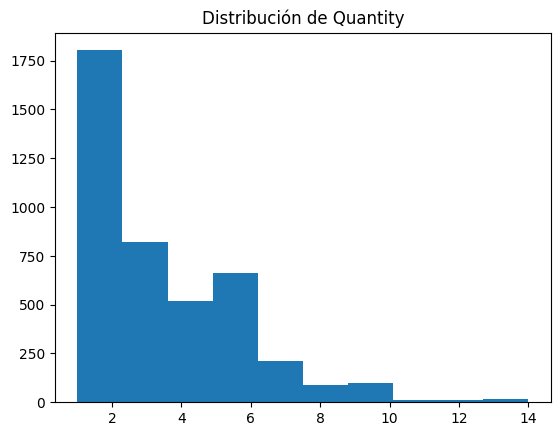

In [67]:
plt.hist(df["Quantity"])
plt.title("Distribución de Quantity")
plt.show()

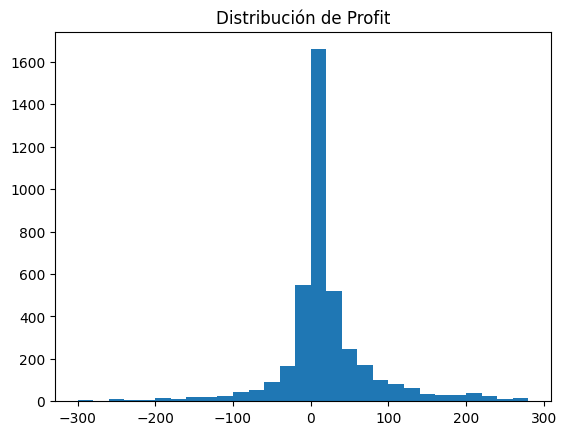

In [90]:
plt.hist(df["Profit"], bins=np.arange(-300, 300, 20))
plt.title("Distribución de Profit")
plt.show()

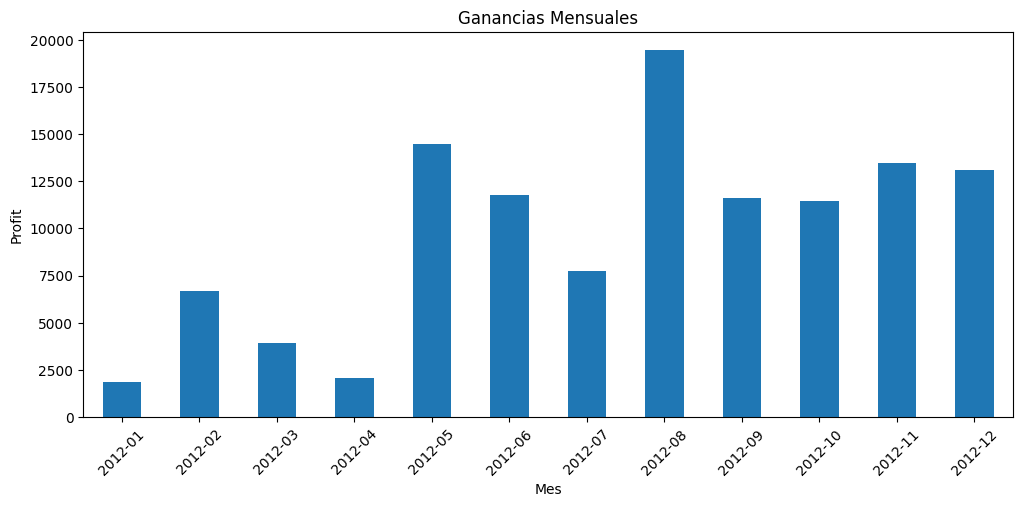

In [93]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["YearMonth"] = df["Order Date"].dt.to_period("M")
ganancias_mensuales = df.groupby("YearMonth")["Profit"].sum()

ganancias_mensuales.plot(kind="bar", figsize=(12,5))
plt.title("Ganancias Mensuales")
plt.xlabel("Mes")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

In [92]:
df["Profit"].sum()

np.float64(117606.90596)

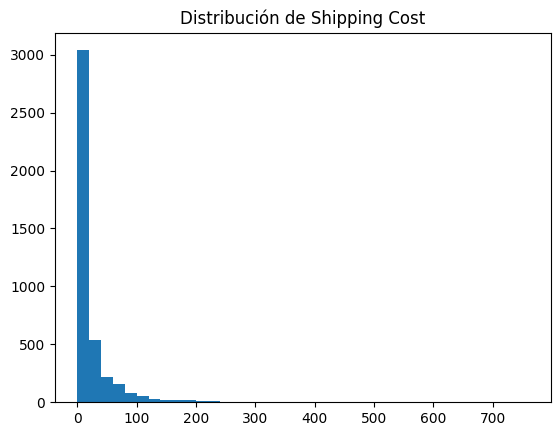

In [75]:
plt.hist(df["Shipping Cost"], bins=np.arange(0, df["Shipping Cost"].max() + 20, 20))
plt.title("Distribución de Shipping Cost")
plt.show()

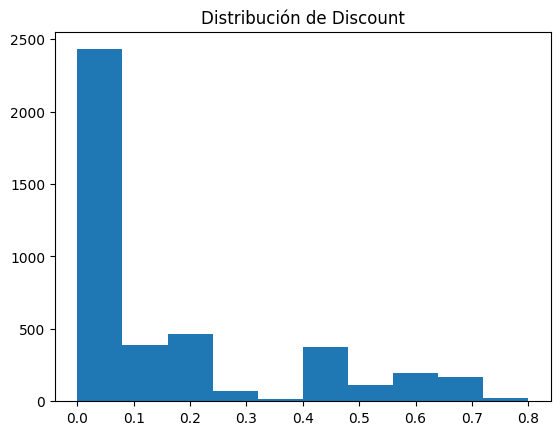

In [76]:
plt.hist(df["Discount"])
plt.title("Distribución de Discount")
plt.show()

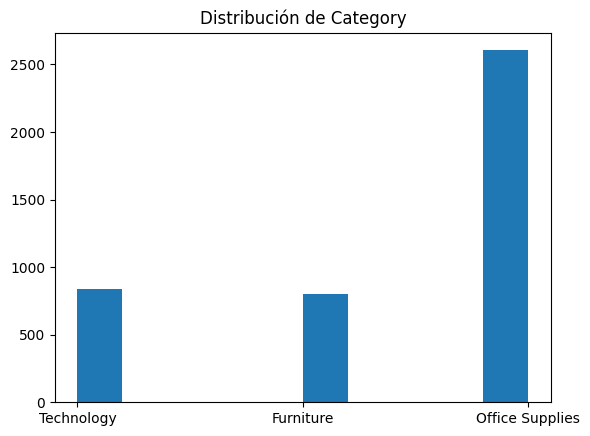

In [77]:
plt.hist(df["Category"])
plt.title("Distribución de Category")
plt.show()

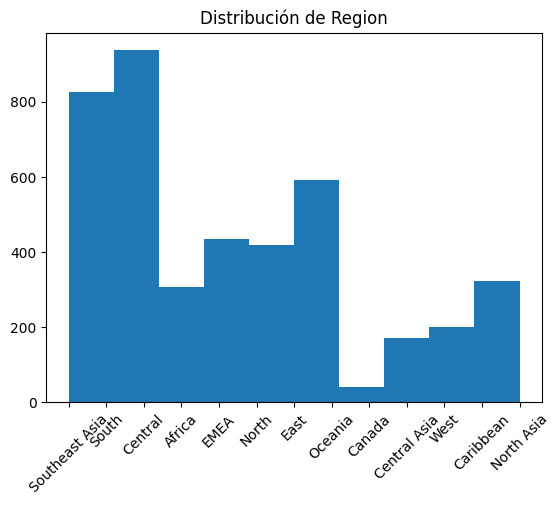

In [80]:
plt.hist(df["Region"])
plt.title("Distribución de Region")
plt.xticks(rotation=45)
plt.show()

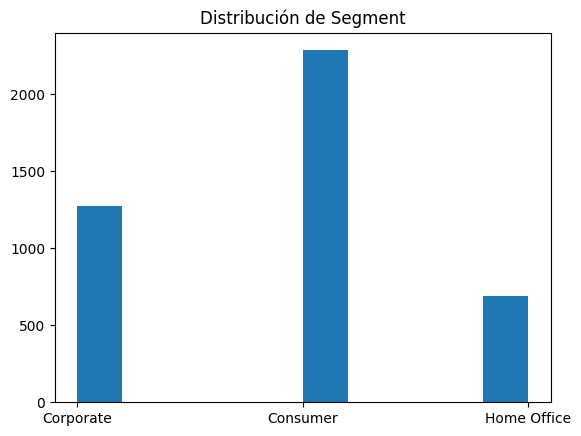

In [83]:
plt.hist(df["Segment"])
plt.title("Distribución de Segment")
plt.show()